# SHAP analysis — tuned Logistic Regression

In [4]:
import joblib
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA   = Path('../data')
MODELS = Path('../models')

NUMERIC_FEATURES = [
    'temperature', 'humidity',
    'temperature_anom', 'wind_speed_anom', 'precipitation_anom',
    'population', 'gdp_per_capita', 'infrastructure_density',
]
CATEGORICAL_FEATURES = ['land_use']
DROP_COLS = ['date', 'lat', 'lon', 'burned_area_ha', 'duration_days',
             'ignition_cause', 'municipality_id', 'target']

# Load model and data
model = joblib.load(MODELS / 'lr_classifier.pkl')

df = pd.read_csv(DATA / 'features.csv', parse_dates=['date'])
X  = df.drop(columns=DROP_COLS)
y  = df['target']

nan_mask = X.isnull().any(axis=1)
X, y     = X[~nan_mask], y[~nan_mask]
dates    = df.loc[~nan_mask, 'date']

test_mask     = dates.dt.year >= 2022
X_test        = X[test_mask][NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_test        = y[test_mask]

print(f'Test set: {len(X_test)} rows')

Test set: 296 rows


In [19]:
model

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidity',
                                                   'temperature_anom',
                                                   'wind_speed_anom',
                                                   'precipitation_anom',
                                                   'population',
                                                   'gdp_per_capita',
                                                   'infrastructure_density']),
                                                 ('cat',
                                                  Pipeline(steps=[('enc',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['land_use'])])),
                ('clf',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42))])

## Logistic Regression coefficients

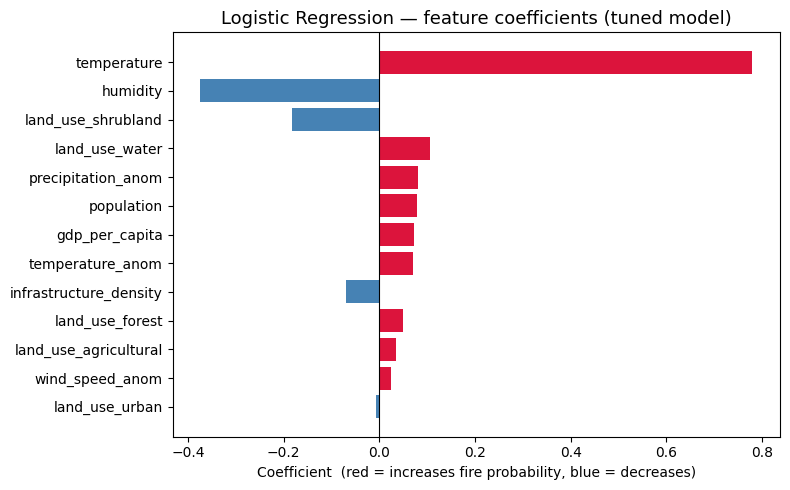

In [5]:
feature_names = model['pre'].get_feature_names_out()
coefs         = model['clf'].coef_[0]

coef_df = (
    pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    .assign(abs_coef=lambda d: d['coefficient'].abs())
    .sort_values('abs_coef', ascending=True)
)
coef_df['feature'] = coef_df['feature'].str.replace(r'^(num__|cat__)', '', regex=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['crimson' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient  (red = increases fire probability, blue = decreases)')
ax.set_title('Logistic Regression — feature coefficients (tuned model)', fontsize=13)
plt.tight_layout()
plt.show()

## What is SHAP?

SHAP (SHapley Additive exPlanations) answers the question: **for a specific prediction, how much did each feature contribute?**

The idea comes from cooperative game theory. Imagine the features are players in a team and the model prediction is the reward. SHAP computes each player's fair share by measuring how much the prediction changes when that feature is added to every possible subset of other features.

For a single prediction, each feature receives a SHAP value:
- **Positive** → pushed the prediction toward fire (target = 1)
- **Negative** → pushed the prediction toward no fire (target = 0)
- The sum of all SHAP values equals the prediction minus the baseline (the average prediction across the dataset)

This makes SHAP both **locally interpretable** (why did the model predict fire for this specific day?) and **globally interpretable** (which features matter most on average?).

## SHAP values

For Logistic Regression + StandardScaler, the SHAP value for feature $i$ on sample $x$ is:

$$\text{SHAP}_i = \text{coefficient}_i \times (x_i - \bar{x}_i)$$

The **ranking** of features by mean |SHAP| is therefore the same as ranking by |coefficient|. The **values** differ slightly because SHAP multiplies the coefficient by the per-sample deviation from the mean, while the coefficient is a fixed number.

On the test set the standard deviation of scaled features may deviate slightly from 1, so mean |SHAP| ≈ |coefficient| but not exactly equal.

**Practical note:** for LR, SHAP and coefficients tell the same story. SHAP becomes much more valuable for non-linear models (Random Forest, XGBoost) where there are no coefficients to read directly.

In [6]:
# Transform test data through the preprocessing step
X_test_transformed = model['pre'].transform(X_test)
feature_names_clean = [
    f.replace('num__', '').replace('cat__', '')
    for f in model['pre'].get_feature_names_out()
]

explainer   = shap.LinearExplainer(model['clf'], X_test_transformed)
shap_values = explainer.shap_values(X_test_transformed)

### Mean absolute SHAP — global feature importance

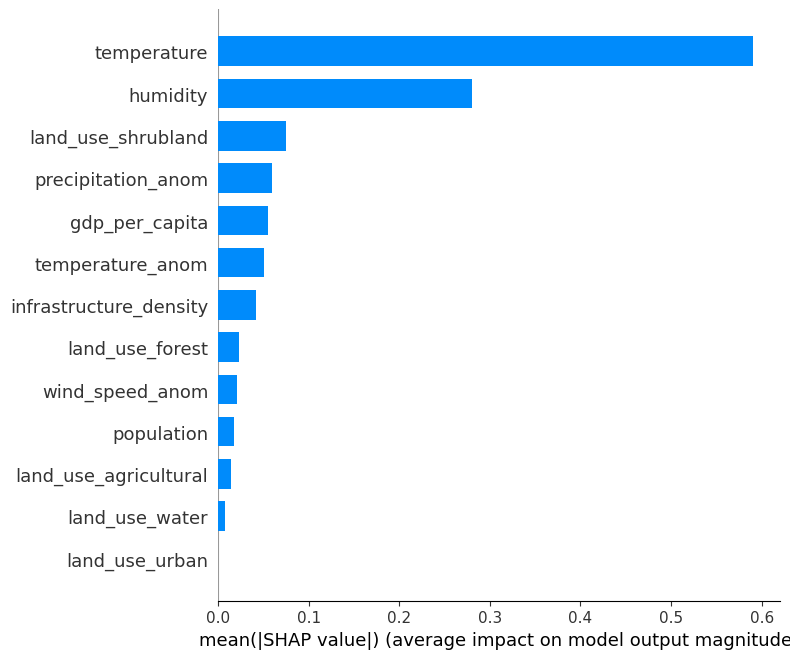

In [7]:
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names_clean, plot_type='bar')

### Beeswarm plot — direction and magnitude per sample

Each dot is one test sample. The x-axis is the SHAP value (positive = pushed toward fire, negative = pushed away). Dots are coloured by the raw feature value: red = high, blue = low.

This plot shows not just which features matter, but **in which direction**: for example, if high temperature (red dots) sits on the positive side, it means hot days increase fire probability.

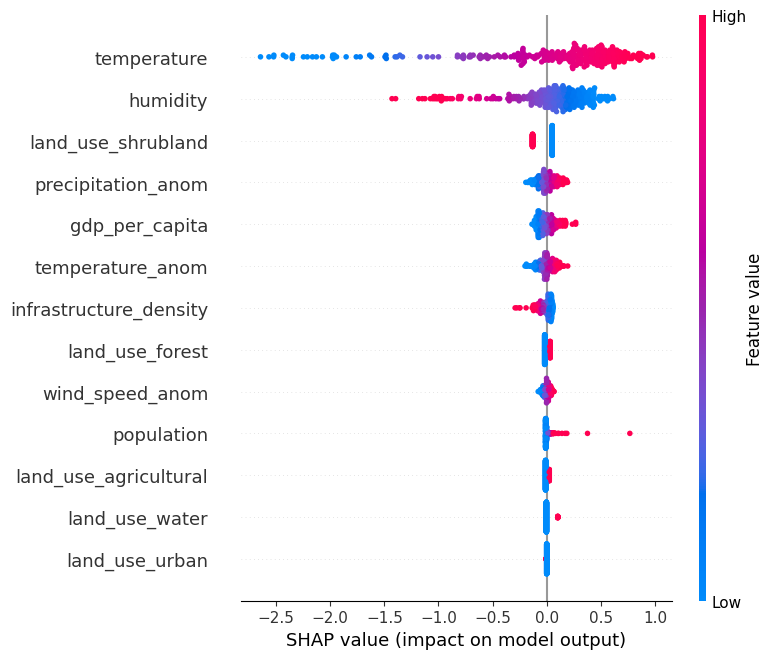

In [8]:
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names_clean)